_Neural Data Science_

Lecturer: Prof. Dr. Philipp Berens, Dr. Jan Lause

Tutors: Jonas Beck, Kyra Kadhim, Jonathan Oesterle, Julius Würzler

Summer term 2026

Student names: Zhidong Zhang, Yuzhe Han, Bach Nguyen

LLM Disclaimer: Github Copilot was used to help with function calling and structure prompting, Claude and Gemini were used (by different members) to help with function understanding and outcome analysis.

# Coding Lab 1

## Introduction

In this coding lab you get to implement a pipeline for spike detection and feature extraction, as presented in the lecture:
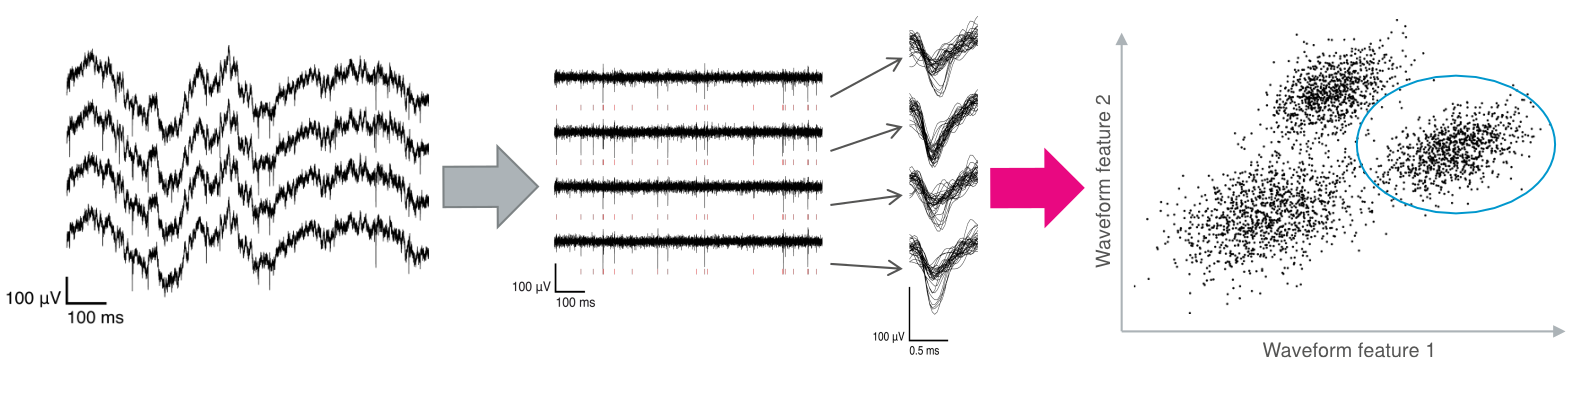

This will later be used for spike sorting (identifying which spike / waveform in the signal was caused by which neuron).

The data used in this notebook was recorded at 30kHz with a tetrode and thus contains the voltage traces of the 4 channels in μV.

_(for more information on the data acquisition, you can have a look at [Ecker et al 2014](https://doi.org/10.1016/j.neuron.2014.02.006), in particular the supplementary material. A similar pipeline is also used in [Ecker et al 2010](https://doi.org/10.1126/science.1179867). Note however that we only use a small portion of the data in this notebook and most of the experiment setup is not relevant here!)_

## Setup
- __Data__: Download the data file ```nds_cl_1.csv``` from ILIAS and save it in a subfolder ```../data/```.
- __Dependencies__: You don't have to use the exact versions of all the dependencies in this notebook, as long as they are new enough. But if you run "Run All" in Jupyter and the boilerplate code breaks, you probably need to upgrade them.


Recommended folder structure:

```
.
├── data/
│   └── nds_cl_1.csv
├── notebooks
│   └── CodingLab1.ipynb
├── matplotlib_style.txt
└── requirements.txt
```

In [ ]:
from __future__ import annotations  # for Python 3.8 and belowimport numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from sklearn.decomposition import PCA

# black is a code formatter (see https://github.com/psf/black).
# It will automatically format the code you write in the cells imposing consistent Python style.
%load_ext jupyter_black

%load_ext watermark
%watermark --time --date --timezone --updated --python --iversions --watermark -p sklearn

Last updated: 2026-04-23 15:14:53 CEST

Python implementation: CPython
Python version       : 3.10.0
IPython version      : 8.39.0

sklearn: 1.7.2

matplotlib: 3.10.8
numpy     : 2.2.6
pandas    : 2.3.3
scipy     : 1.15.3
sklearn   : 1.7.2

Watermark: 2.6.0



In [ ]:
# matplotlib style file
# Template for style file: https://matplotlib.org/stable/tutorials/introductory/customizing.html#customizing-with-style-sheets
plt.style.use("../matplotlib_style.txt")

## Load data

In [ ]:
fs = 30000.0  # sampling rate of the signal in Hz
dt = 1 / fs
cols = ["Ch1", "Ch2", "Ch3", "Ch4"]
x = pd.read_csv("../data/nds_cl_1.csv", header=0, names=cols)

In [ ]:
x.describe()

,Ch1,Ch2,Ch3,Ch4
count,1.920000e+07,1.920000e+07,1.920000e+07,1.920000e+07
mean,3.600331e+00,-8.850918e-01,2.864284e-01,2.210982e+00
std,5.824474e+02,6.014818e+02,6.464363e+02,6.126105e+02
min,-3.607000e+03,-3.739000e+03,-3.871000e+03,-3.750000e+03
25%,-3.460000e+02,-3.610000e+02,-3.950000e+02,-3.640000e+02
50%,1.200000e+01,8.000000e+00,-1.000000e+00,1.000000e+01
75%,3.650000e+02,3.720000e+02,4.010000e+02,3.810000e+02
max,2.873000e+03,3.004000e+03,3.099000e+03,3.017000e+03


## Task 1: Filter Signal

In order to detect action potentials, the first step is to filter out low frequency fluctuations (LFP) and high frequency noise. Determine appropriate filter settings and implement the filtering in the function ```filter_signal()```. A typical choice for this task would be a <mark>butterworth filter</mark>.

Plot a segment of the raw signal and the filtered signal for all four channels with matching y-axis. The segment you choose should contain spikes. When you apply the function also test different filter settings.

*Grading: 3 pts*


In [ ]:
def filter_signal(
    x: pd.DataFrame,
    fs: float,
    low: float,
    high: float,
    order: int = 3,
    output: str = "ba",
) -> pd.DataFrame:
    """Filter raw signal x.

    Parameters
    ----------

    x: pd.DataFrame, (n_samples, n_channels)
        Each column in x is one recording channel.

    fs: float
        Sampling frequency.

    low, high: float, float
        Passband in Hz for the butterworth filter.

    order: int
        The order of the Butterworth filter. Default is 3, but you should try
        changing this and see how it affects the results.


    Returns
    -------

    y: pd.DataFrame, (n_samples, n_channels)
        The filtered x. The filter delay is compensated in the output y.


    Notes
    ----

    1. Try exploring different filters and filter settings. More info:
    https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html

    2. The output signal should be phase-shift compensated. More info:
    https://dsp.stackexchange.com/a/19086

    """
    # -----------------------------------------------------------------
    # implement a suitable filter and apply it to the input data (1pt)
    # -----------------------------------------------------------------
    if output == "sos":
        # Output 'sos' (second-order sections)
        sos = signal.butter(
            N=order, Wn=[low, high], btype="bandpass", fs=fs, analog=False, output="sos"
        )
        x_filtered = signal.sosfilt(
            sos, x.to_numpy(dtype=float), axis=0
        )  # denote the data axis
        filter_param = sos

    elif output == "ba":
        # Output 'ba' (numerator/denominator)
        b, a = signal.butter(
            N=order, Wn=[low, high], fs=fs, btype="bandpass", analog=False
        )  # fs used for nomalization
        x_filtered = signal.filtfilt(
            b, a, x.to_numpy(dtype=float), axis=0
        )  # denote the data axis
        filter_param = (b, a)

    return pd.DataFrame(x_filtered, index=None), filter_param

In [ ]:
xf, filter_param = filter_signal(x, fs, 500, 4000)

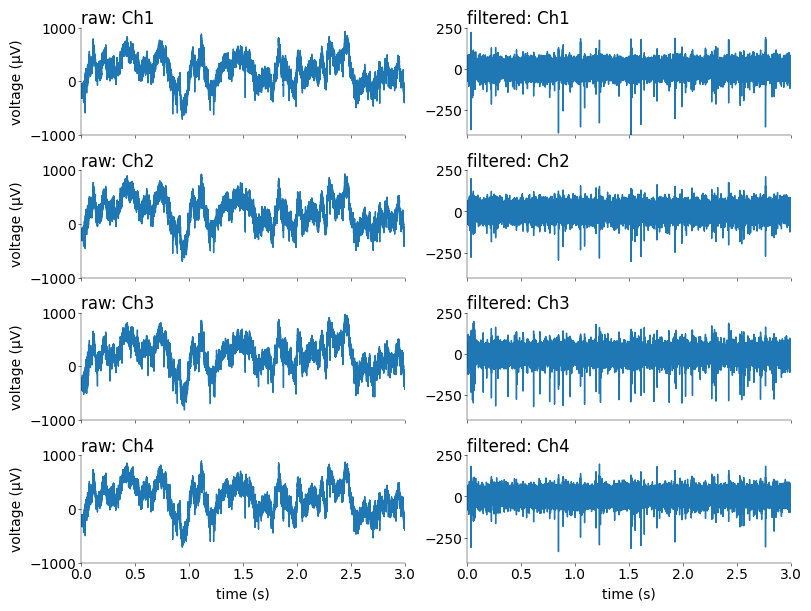

In [ ]:
mosaic = [
    ["raw: Ch1", "filtered: Ch1"],
    ["raw: Ch2", "filtered: Ch2"],
    ["raw: Ch3", "filtered: Ch3"],
    ["raw: Ch4", "filtered: Ch4"],
]
fig, ax = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(8, 6), layout="constrained", dpi=100
)

# ------------------------------------------------------------------------------------
# Plot raw and filtered signals for all 4 channels and answer the questions (1+1 pts)
# ------------------------------------------------------------------------------------

T = 100000
t = np.arange(0, T) * dt

for i, (raw, filtered) in enumerate(mosaic):
    ax[raw].set_xlim((0, 3))
    ax[raw].set_ylim((-1000, 1000))

    ax[filtered].set_xlim((0, 3))
    ax[filtered].set_ylim((-400, 250))

    # Add labels and title
    ax[raw].set_ylabel("voltage (μV)")
    ax[raw].set_title(raw, loc="left")
    ax[filtered].set_title(filtered, loc="left")
    if i != 3:
        ax[raw].set_xticklabels([])
        ax[filtered].set_xticklabels([])
    else:
        ax[raw].set_xlabel("time (s)")
        ax[filtered].set_xlabel("time (s)")

    # Add data (same time axis in seconds for raw and filtered)
    ax[raw].plot(t, x.iloc[:T, i].to_numpy())
    ax[filtered].plot(t, xf.iloc[:T, i].to_numpy())

plt.show()

---

Here we explore different filters:

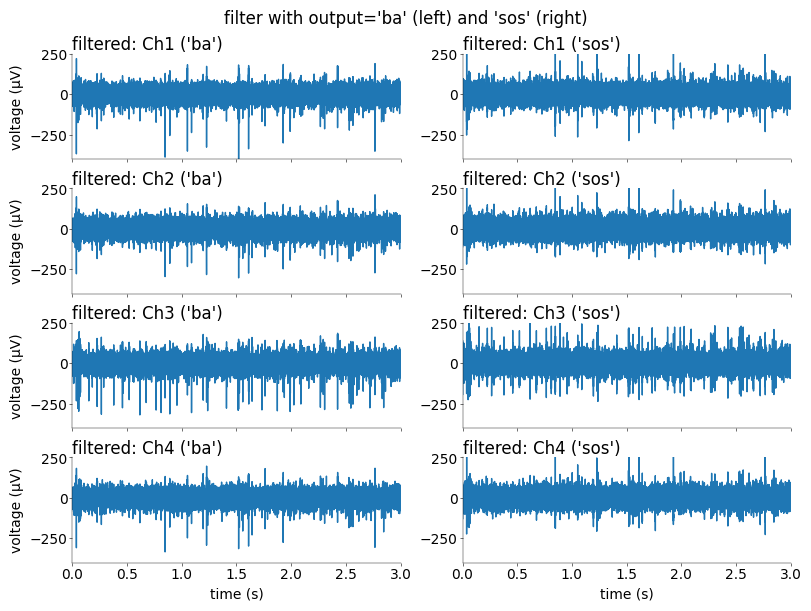

In [ ]:
xf_sos, filter_param_sos = filter_signal(x, fs, 500, 4000, output="sos")

mosaic_sos = [
    ["filtered: Ch1 ('ba')", "filtered: Ch1 ('sos')"],
    ["filtered: Ch2 ('ba')", "filtered: Ch2 ('sos')"],
    ["filtered: Ch3 ('ba')", "filtered: Ch3 ('sos')"],
    ["filtered: Ch4 ('ba')", "filtered: Ch4 ('sos')"],
]
fig, ax = plt.subplot_mosaic(
    mosaic=mosaic_sos,
    figsize=(8, 6),
    layout="constrained",
    dpi=100,
)

# ------------------------------------------------------------------------------------
# Plot raw and filtered signals for all 4 channels and answer the questions (1+1 pts)
# ------------------------------------------------------------------------------------

T = 100000
t = np.arange(0, T) * dt


plt.suptitle("filter with output='ba' (left) and 'sos' (right)", fontsize=12)

for i, (ba, sos) in enumerate(mosaic_sos):
    ax[ba].set_xlim((0, 3))
    ax[ba].set_ylim((-400, 250))

    ax[sos].set_xlim((0, 3))
    ax[sos].set_ylim((-400, 250))

    # Add labels and title
    ax[ba].set_ylabel("voltage (μV)")
    ax[ba].set_title(ba, loc="left")
    ax[sos].set_title(sos, loc="left")
    if i != 3:
        ax[ba].set_xticklabels([])
        ax[sos].set_xticklabels([])
    else:
        ax[ba].set_xlabel("time (s)")
        ax[sos].set_xlabel("time (s)")

    # Add data (same time axis in seconds for ba and sos)
    ax[sos].plot(t, xf_sos.iloc[:T, i].to_numpy())
    ax[ba].plot(t, xf.iloc[:T, i].to_numpy())

plt.show()

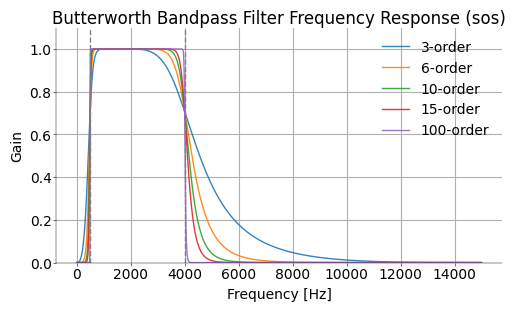

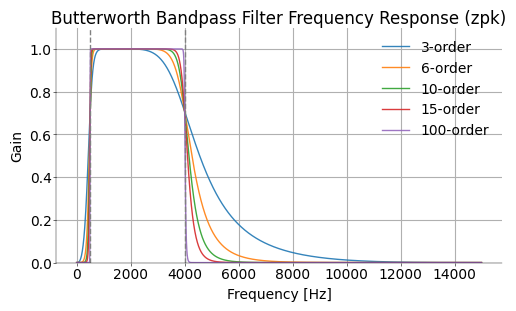

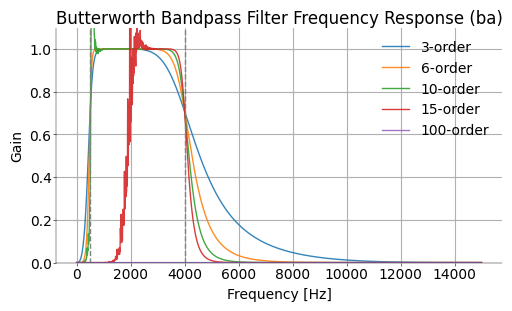

In [ ]:
# Plot different filter under different order

# order = 15
Wn = [500, 4000]
worN = 2000

alpha = 0.9
orders = [3, 6, 10, 15, 100]


# sos
plt.figure(figsize=(5, 3))
for order in orders:
    sos = signal.butter(
        N=order, Wn=Wn, btype="bandpass", fs=fs, analog=False, output="sos"
    )
    w_sos, h_sos = signal.sosfreqz(sos, worN=worN, fs=fs)
    gain_sos = np.abs(h_sos)

    plt.plot(w_sos, gain_sos, alpha=alpha, label=f"{order}-order")
plt.title(f"Butterworth Bandpass Filter Frequency Response (sos)")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Gain")
plt.ylim(0, 1.1)
plt.axvline(500, color="gray", linestyle="--")
plt.axvline(4000, color="gray", linestyle="--")
plt.grid(True)
plt.legend()

plt.show()

# zpk
plt.figure(figsize=(5, 3))
for order in orders:
    z, p, k = signal.butter(
        N=order, Wn=Wn, btype="bandpass", fs=fs, analog=False, output="zpk"
    )
    w_zpk, h_zpk = signal.freqz_zpk(z, p, k, worN=worN, fs=fs)
    gain_zpk = np.abs(h_zpk)

    plt.plot(w_zpk, gain_zpk, alpha=alpha, label=f"{order}-order")
plt.title(f"Butterworth Bandpass Filter Frequency Response (zpk)")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Gain")
plt.ylim(0, 1.1)
plt.axvline(500, color="gray", linestyle="--")
plt.axvline(4000, color="gray", linestyle="--")
plt.grid(True)
plt.legend()

# ba
plt.figure(figsize=(5, 3))
for order in orders:
    b, a = signal.butter(
        N=order, Wn=Wn, fs=fs, btype="bandpass", analog=False, output="ba"
    )  # fs used for normalization
    w_ba, h_ba = signal.freqz(b, a, worN=worN, fs=fs)
    gain_ba = np.abs(h_ba)

    plt.plot(w_ba, gain_ba, alpha=alpha, label=f"{order}-order")
plt.title(f"Butterworth Bandpass Filter Frequency Response (ba)")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Gain")
plt.ylim(0, 1.1)
plt.axvline(500, color="gray", linestyle="--")
plt.axvline(4000, color="gray", linestyle="--")
plt.grid(True)
plt.legend()

plt.show()

### Questions
1) Explain your implementation: Which filter and parameters did you choose and why?

Bandpass filter with `output='ba'` and `order=3`.

- `output='ba'` with `filtfilt`:  We used filtfilt rather than lfilter for a critical reason: filtfilt performs zero-phase filtering by applying the filter twice — once forward and once backward in time. The two passes cancel each other's phase delays, so the output signal has no phase shift at any frequency. 
- `order=3`: It is high enough for a clean filtering via abrupt edges of the band spectrum. When the order increase above 10, the increase of the slope near the band edge is not satisfying at the higher computation cost.

> More exploration about the filter with different `output` are made shown above. 
>
> - It shows that 'ba' filter is not stable when the order reaches 15 with a shift in the curve. The spectrum of 'zpk' and 'sos' are stable and almost the same, but 'zpk' cannot be directly used without being transformed to 'sos' or 'ba' format. In this case `order=3` is sufficient for our need thus a 'ba' filter is good enough. 
>
> - What's more, the filtered signals by 'sos' are slightly differrent form that by 'ba', that is the values of spikes are shifted towards central 0 line for 'sos'. It can affect further detection as they differ in standard variation and the threshold. It is also recommended by scikit-learn to use 'sos' for general purpose as it is more stable across different orders picked.

2) Which parameters of the function can be adjusted, which are determined by the experiment setup? What is the effect of the adjustable parameters?

- Determined by the setup: `fs`
- Can be adjusted: 
    - passband `low` and `high`: they determines the band where the frequency component contained in the signal can be preserved.
    - the order of the Butterworth filter `order`: A higher order means a larger slope near the band edge, and result in less non-targeted information preserved.

3) How does the filtered signal look compared to the original? Why is this helpful as preprocessing in our spike detection pipeline?

Compared to the raw signal, the filtered signal shows two main changes. First, the slow baseline drift (caused by LFP — the summed slow oscillations of large neural populations) is removed, so the signal fluctuates around zero rather than drifting up and down. Second, high-frequency noise is suppressed, making the signal smoother between spikes.
As a result, action potentials become clearly visible as sharp, isolated negative deflections against a flat baseline. This is essential for the threshold-based spike detection in the next step: if the LFP were still present, large slow fluctuations would cross the threshold and be falsely detected as spikes. By removing both the LFP and high-frequency noise, the filtered signal greatly improves the signal-to-noise ratio specifically in the frequency band where spikes occur.

## Task 2: Detect action potentials

Action potentials are usually detected by finding large-amplitude deflections in the continuous signal. A good choice of threshold for detecting spikes is important. If it is too low, you will detect too many low amplitude events (noise); if it is too high, you run the risk of missing good spikes. Implement an automatic procedure to obtain a reasonable threshold and detect the times when spikes occurred in the function ```detect_spikes()```.

Plot a segment of the filtered signal for all four channels with matching y-axis and indicate the time points where you detected spikes, also **plot the threshold**.

*Grading: 4 pts*

In [ ]:
def detect_spikes(
    x: np.ndarray, fs: float, N: int = 5, lockout: float = 1.0
) -> tuple[np.ndarray, np.ndarray, np.float64]:
    """Detect spikes in the signal x and compute a threshold.

    Parameters
    ----------

    x: np.array (n_samples, n_channels)
        The filtered signal from Task 1.

    fs: float
        the sampling rate (in Hz).

    N: int
        An arbitrary number with which you multiply with the standard deviation
        to set a threshold that controls your false positive rate. Default is 5
        but you should try changing it and see how it affects the results.

    lockout: float
        a window of 'refractory period', within which there's only one spike.
        Default is 1ms but you should also try changing it.


    Returns
    -------

    s: np.array, (n_spikes, )
        Spike location / index in the signal x.

    t: np.array, (n_spikes, )
        Spike time in ms. By convention the time of the zeroth sample is 0 ms.

    thrd: float
        Threshold = -N * sigma.


    Tips
    ----

    You can use scipy functions like find_peaks for the detection.
    Note: There are four channels in signal x.

    """
    # --------------------------------------------------------------
    # compute the robust s.d. and calculate the threshold (0.5 pts)
    # --------------------------------------------------------------
    sigma = np.median(np.abs(x - np.median(x, axis=0)) / 0.6745)
    thrd = -N * sigma
    print(f"Robust standard deviation (sigma): {sigma:.2f}")
    print(f"Threshold: {thrd:.2f}")

    # --------------------------
    # find all spikes (1.5 pts)
    # --------------------------
    s = []
    for ch in range(
        x.shape[1]
    ):  # find all peaks in each channel and combine them together
        peaks, _ = signal.find_peaks(
            -x[:, ch], height=abs(thrd)
        )  # only detect negative peaks ***
        s.extend(peaks)

    s = list(set(s))  # remove duplicates (if any) and sort the spike indices
    s.sort()

    # remove spikes that are too close to each other (within the lockout window)
    lockout_samples = lockout * fs / 1000  # convert lockout from ms to samples number

    mask = np.ones(len(s), dtype=bool)  # initialize a mask for valid spikes
    last_valid_spike = s[0]

    from tqdm import tqdm

    for i in tqdm(range(1, len(s)), desc="Removing spikes during refractory period"):
        if s[i] - last_valid_spike < lockout_samples:
            mask[i] = False  # mark the second spike in the lockout window as invalid
        else:
            last_valid_spike = s[i]  # update the last valid spike index
    s = np.array(s)[mask]
    t = s / fs * 1000  # Convert to ms
    return s, t, thrd

In [ ]:
s, t, thrd = detect_spikes(xf.to_numpy(), fs, N=5, lockout=1.0)

print(f"Number of detected spikes: {len(s)}")

Robust standard deviation (sigma): 34.09
Threshold: -170.47


Removing spikes during refractory period: 100%|██████████| 34506/34506 [00:00<00:00, 972253.30it/s]

Number of detected spikes: 20625


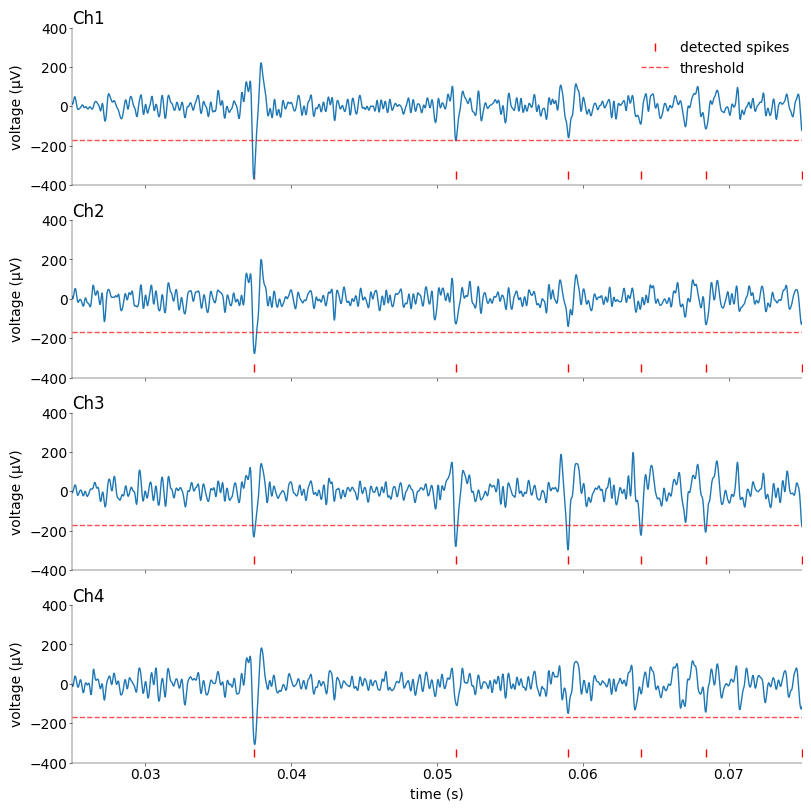

In [ ]:
mosaic = [
    ["Ch1"],
    ["Ch2"],
    ["Ch3"],
    ["Ch4"],
]
fig, ax = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(8, 8), layout="constrained", dpi=100
)

# ------------------------------------------------------------------------------
# plot signal, threshold and detected spikes and answer the questions (1+1 pts)
# ------------------------------------------------------------------------------

for i, col in enumerate(cols):

    ax[col].set_ylim((-400, 400))
    ax[col].set_xlim((0.025, 0.075))
    # ax[col].set_xlim((0.0, 2))
    ax[col].set_ylabel("voltage (μV)")

    ax[col].set_title(col, loc="left")

    if col != "Ch4":
        ax[col].set_xticklabels([])
    else:
        ax[col].set_xlabel("time (s)")

    # Add data
    ax[col].scatter(
        t / 1000,
        np.ones_like(t) * (-350),
        color="red",
        label="detected spikes",
        marker="|",
    )
    # ax[col].vlines(
    #     t_spikes / 1000,
    #     ymin=-400,
    #     ymax=400,
    #     color="gray",
    #     linestyle="--",
    #     label="detected spikes",
    #     alpha=0.7,
    # )
    ax[col].plot(np.arange(0, T) * dt, xf.iloc[:T, i].to_numpy())
    ax[col].axhline(thrd, color="red", linestyle="--", label="threshold", alpha=0.7)
    # ax[col].axhline(-thrd, color="red", linestyle="--", alpha=0.7)
    if col == "Ch1":
        ax[col].legend()

### Questions

1) Are the detected time points well aligned with prominent extrema in the signal? Also compare your detections across channels.

Yes. But the prominent extrema vary in amplitude across channels, which means a time point of a spike would be aligned well with all four channels, but not all of them reach the threshold at that point.

2) Take one feature of the spikes and explain how that can help us identifying the source neuron of a spike (only based on visual examination of the plot).

The relative amplitude across channels is a useful feature. Since each neuron occupies a fixed position, its spikes always produce the same amplitude ratio across the four electrodes, larger on closer electrodes and smaller on distant ones. This acts as a spatial fingerprint. Additionally, spikes from different neurons may differ in waveform shape, for example in width or the ratio of positive to negative peak, providing a second visual cue. In the plot, one can observe that the 1st spikes is dominated by Ch1 while others are largest in Ch3, and their waveform shapes differ, suggesting the difference in source neurons.

## Task 3: Extract waveforms
For later spike sorting we need the waveforms of all detected spikes. Extract the waveforms segments (1 ms) on all four channels for each spike time (as a result each spike is represented by a 4x30 element matrix). Implement this procedure in the function ```extract_waveforms()```.

Plot (a) the first 100 spikes you detected and (b) the 100 largest spikes you detected.
Are there a lot of very small spikes (likely noise) among your detected spikes? If so your threshold may be too low. Can you see obvious artifacts, not looking like spikes at all?

*Grading: 3 pts*

In [ ]:
def extract_waveforms(x: np.ndarray, s: np.ndarray) -> np.ndarray:
    """Extract spike waveforms at times s (given in samples)
    from the filtered signal `xf` using a fixed window around the
    times of the spikes.

    Parameters
    ----------

    x: np.array (n_samples, n_channels)
        The filtered signal.

    s: np.array, (n_spikes, )
        Spike time in samples.


    Return
    ------

    w: np.array, (n_spikes, length_window, n_channels)
        Waveforms. (You don't have to get the exact same
        shape as we noted here. It's just the shape of w
        that can be easily retrieved via broadcasting.)


    Notes
    -----

    More on Numpy Broadcasting
    https://jakevdp.github.io/PythonDataScienceHandbook/02.05-computation-on-arrays-broadcasting.html

    """
    # -------------------------------
    # extract spike waveforms (1 pt)
    # -------------------------------
    length_window = int(1.0 * fs / 1000)
    w = []
    for i, _ in enumerate(cols):
        x_i = x[:, i]
        waveforms_i = [
            x_i[spike_time - length_window // 3 : spike_time + length_window * 2 // 3]
            for spike_time in s
        ]  # (n_spikes, length_window)
        w.append(waveforms_i)

    w = np.array(w).transpose(
        1, 2, 0
    )  # (n_channels, n_spikes, length_window) -> (n_spikes, length_window, n_channels)
    return w

In [ ]:
w = extract_waveforms(xf.to_numpy(dtype=float), s)

Plot first 100 spike waveforms

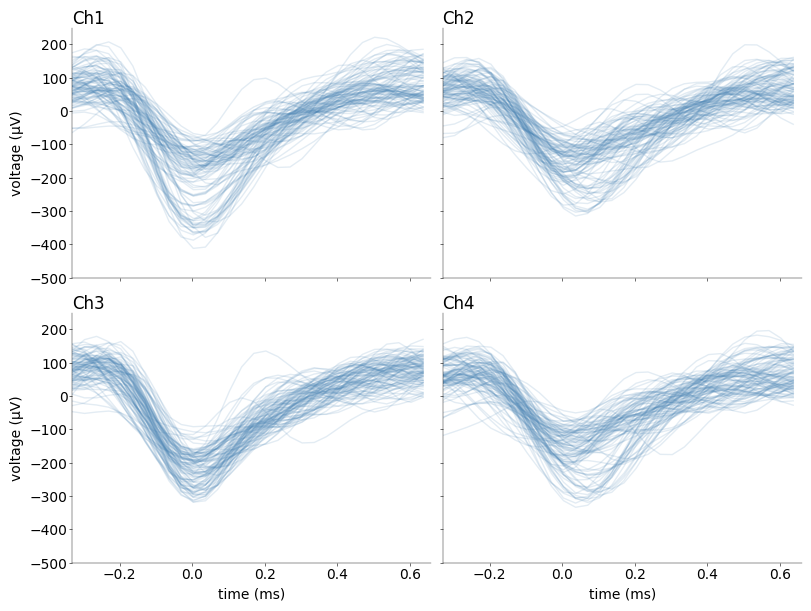

In [ ]:
# ---------------------------------------------------------------------
# plot first and largest 100 spikes and answer the questions (1+1 pts)
# ---------------------------------------------------------------------

# first 100 spikes

mosaic = [
    ["Ch1", "Ch2"],
    ["Ch3", "Ch4"],
]
fig, ax = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(8, 6), layout="constrained", dpi=100
)

# cols = ["Ch1", "Ch2", "Ch3", "Ch4"]
for i, col in enumerate(cols):

    # labeling etc
    ax[col].set_ylim((-500, 250))
    ax[col].set_xlim((-0.33, 0.66))
    ax[col].set_title(col, loc="left")
    if col == "Ch3" or col == "Ch4":
        ax[col].set_xlabel("time (ms)")
    else:
        ax[col].set_xticklabels([])
    if col == "Ch1" or col == "Ch3":
        ax[col].set_ylabel("voltage (μV)")
    else:
        ax[col].set_yticklabels([])

    # ax[col].axvline(0, color="red", linestyle="--", alpha=0.5)
    # Add data
    for j in range(100):
        ax[col].plot(
            np.arange(w.shape[1]) / fs * 1000 - 0.33,
            w[j, :, i],
            color="steelblue",
            alpha=0.15,
        )

Plot largest 100 spike waveforms

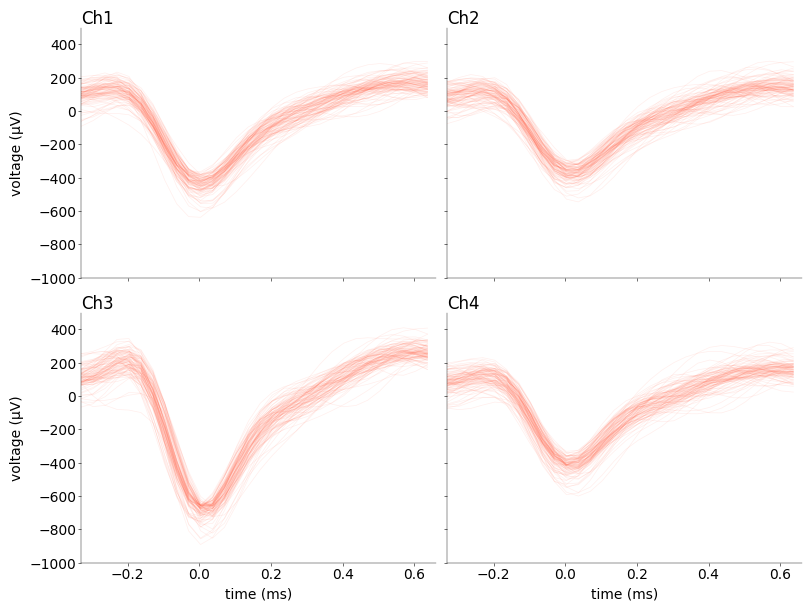

In [ ]:
# largest 100 spikes

fig, ax = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(8, 6), layout="constrained", dpi=100
)

amplitudes = np.min(
    w, axis=(1, 2)
)  # 因为spike是大负峰所以是min，w为(n_spikes, 30, 4)，取出12维度 每个spike给出最小的数字 不管什么时间节点什么channel
largest_indices = np.argsort(amplitudes)[:100]

for i, col in enumerate(cols):

    # labeling etc
    ax[col].set_ylim((-1000, 500))
    ax[col].set_xlim((-0.33, 0.66))
    ax[col].set_title(col, loc="left")
    if col == "Ch3" or col == "Ch4":
        ax[col].set_xlabel("time (ms)")
    else:
        ax[col].set_xticklabels([])
    if col == "Ch1" or col == "Ch3":
        ax[col].set_ylabel("voltage (μV)")
    else:
        ax[col].set_yticklabels([])

    for j in largest_indices:
        ax[col].plot(
            np.arange(w.shape[1]) / fs * 1000 - 0.33,
            w[j, :, i],
            color="tomato",
            alpha=0.1,
            linewidth=0.5,
        )

### Questions

1) Describe the shape of the spikes.

The shape shows a up-down-up pattern, with the changes around 400μV from the top to the bottom.

1) Do the waveforms tend to be similar? If spikes have a similar waveform, what could that mean - and what does it mean if the waveforms look different?

The largest 100 spikes form a tight bundle across all channels, suggesting they originate from a single neuron firing with a stereotyped waveform. The first 100 spikes show much more variability in amplitude and shape, indicating contributions from multiple neurons at different distances from the electrodes. This variability motivates spike sorting: to separate the mixed detections into groups corresponding to individual source neurons.

## Task 4: Extract features using PCA
Compute the first three PCA features on each channel separately in ```extract_features()```. You can use a available PCA implementation or implement it yourself. After that, each spike is represented by a 12 element vector. Compute the fraction of variance captured by these three PCs. Also return the obtained parameters of the PCA

For one channel, plot the mean and the first three principal axes as calculated by the PCA in the feature space. Interprete them in light of the plots in the previous tasks.

For all pairwise combinations of channels, plot the resulting features of the 1st PCs as scatter plots against each other. Do you see clusters visually?

*Grading: 6 pts*

## PCA
### Questions (1 pt)
1) If we input the data from each channel separately to a PCA, what are the feature dimension of the input?

(n_spikes, 30)

2) Therefore, what do the Principal Axes the PCA computes represent?

It represent the linear combination of the signal at all time points in the window, which explains the most variance (or information) of the original signal.

3) Does it make sense to apply preprocessing steps, such as normalization? Have a look at the [scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html). What is applied by default?

Yes, as some basic preprocessing steps might make PCA decomposition easier, as long as preprocessing does not change the shape of the data distribution. Evidently, in the `sklearn` PCA source code, mean-centering is applied by default (though whitening is not to make sure that the method generalizes).

In [ ]:
def extract_features(w: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Extract features for spike sorting from the waveforms w.

    Do PCA on the waveforms of each channel separately,
    then concatenate the first three principal components
    of each channels into one numpy array (`b`).


    Parameter
    ---------

    w: np.ndarray, (n_spikes, length_window, n_channels)
        Waveforms from Task 3.


    Return
    ------

    b: np.ndarray, (n_spikes, n_feature)
        the transformed data
    means: np.ndarray, (n_channels, length_window)
        means per channel
    principal_components: np.ndarray, (n_channels, 3, length_window)
        the 'principal axes' obtained by the pca


    Notes
    -----

    You can use PCA from sklearn.

    More on PCA
    https://jakevdp.github.io/PythonDataScienceHandbook/05.09-principal-component-analysis.html

    """

    # ----------------------------------------------
    # obtain first 3 principle components (1.5 pts)
    # ----------------------------------------------
    principal_components = []
    b = []
    ref_components = None  # reference components to make directions of PCs consistent across channels

    for i, col in enumerate(cols):
        pca = PCA(n_components=3)
        pca.fit(w[:, :, i])

        # -----------------------------------------------------------------------------------------------------
        # Print the fraction of variance explained by the three components combined for each channel (0.5 pts)
        # -----------------------------------------------------------------------------------------------------
        var_explained_ratio = pca.explained_variance_ratio_
        print(
            f"Variance explained by the first 3 components combined for channel {col}: {var_explained_ratio[0] * 100:.2f}% + {var_explained_ratio[1] * 100:.2f}% + {var_explained_ratio[2] * 100:.2f}% = {var_explained_ratio.sum() * 100:.2f}%"
        )

        # Check if the direction of the PCs is consistent across channels.
        b_i = pca.transform(w[:, :, i])[:, :3]  # (n_spikes, 3)
        comps = pca.components_.copy()  # (3, length_window)

        if ref_components is None:
            ref_components = comps
        else:
            dot_products = np.sign(np.sum(comps * ref_components, axis=1))  # (3,)
            flip_idx = np.where(dot_products < 0)[0]
            b_i[:, flip_idx] *= -1
            comps[flip_idx] *= -1

        b.append(b_i)
        principal_components.append(comps)

    principal_components = np.array(
        principal_components
    )  # (n_channels, 3, length_window)
    b = np.concatenate(
        b, axis=1
    )  # (n_spikes, n_feature), n_feature= 3 dimension * 4 channels = 12
    means = np.mean(w, axis=0)  # (length_window, n_channels)

    return b, means, principal_components

In [ ]:
b, means, principal_components = extract_features(w)

Variance explained by the first 3 components combined for channel Ch1: 57.55% + 16.47% + 8.02% = 82.05%
Variance explained by the first 3 components combined for channel Ch2: 45.91% + 20.17% + 10.75% = 76.83%
Variance explained by the first 3 components combined for channel Ch3: 50.55% + 19.98% + 9.29% = 79.82%
Variance explained by the first 3 components combined for channel Ch4: 48.70% + 19.91% + 10.50% = 79.10%


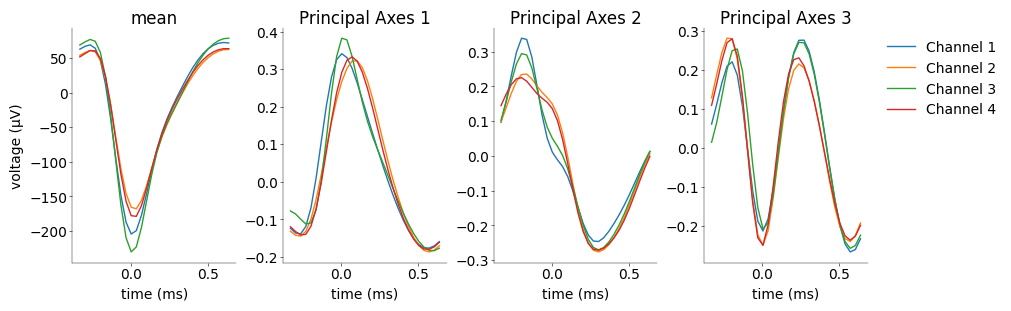

In [ ]:
# ------------------------------------------------------------------------------------------------------------------
# Plot the mean of each channel and the three principal axes obtained by the PCA and answer the questions (1+1 pts)
# ------------------------------------------------------------------------------------------------------------------

mosaic = [
    ["mean", "Principal Axes 1", "Principal Axes 2", "Principal Axes 3"],
]
fig, ax = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(10, 3), layout="constrained", dpi=100
)

x_axis = np.arange(w.shape[1]) / fs * 1000 - 0.33

for channel in range(4):
    for i, mo in enumerate(np.ravel(mosaic)):

        ax[mo].set_xlabel("time (ms)")
        ax[mo].set_title(mo)

        # Add data
        if mo == "mean":
            ax[mo].plot(
                x_axis,
                means[:, channel],
            )
        else:
            ax[mo].plot(
                x_axis,
                principal_components[channel, i - 1, :],
            )

ax[mosaic[0][0]].set_ylabel("voltage (μV)")
ax[mosaic[0][-1]].legend(
    ["Channel " + str(i + 1) for i in range(4)],
    bbox_to_anchor=(1.04, 1),
    loc="upper left",
)
plt.show()

### Questions

1) Compare the plot to the plots of the other tasks. What do you observe?

The mean waveforms closely match the central tendency of the spike bundles seen in Task 3. The first principal axis has a shape very similar to the mean, confirming that PC1 primarily captures overall amplitude scaling. PC2 and PC3 show more complex oscillatory shapes with multiple zero crossings, corresponding to the subtler shape variability visible in the spread of waveforms in Task 3. Across all four channels, the shapes of the principal axes are consistent but differ in amplitude, reflecting the channel-dependent amplitude profiles observed in Task 2.

2) What does the mean look like? Does this match your expectations?

The mean waveform shows the expected triphasic shape: a small positive onset around -0.2 ms, a large negative peak at t = 0 ms, and a slow positive recovery toward 0.6 ms. This matches expectations since the mean is the average of all detected spikes, which share this common waveform structure. The negative peak is deepest in Ch2 and Ch3, consistent with the source neuron being located closest to those electrodes, as observed in Task 3.

3) Explain what it means if a spike has a high value in the first dimension. What is the effect of the other dimensions?

Since PC1 has a shape similar to the mean waveform, a spike with a high absolute value in the first dimension has a large overall amplitude, meaning it was generated by a neuron close to the electrode. The sign indicates direction: a large negative PC1 score corresponds to a spike with a deep negative trough, while a value near zero means a small spike close to the mean amplitude. PC2 captures the next most important mode of variation independent of amplitude, such as differences in waveform width or asymmetry between the negative and positive phases. PC3 captures the oscillatory component or the temporal structure of the spike. Together, PC2 and PC3 allow spikes from different neurons to be distinguished even when their amplitudes are similar, since neurons can differ in waveform shape as well as size.

Text(0.5, 0.98, 'Pairwise 1st PCs')

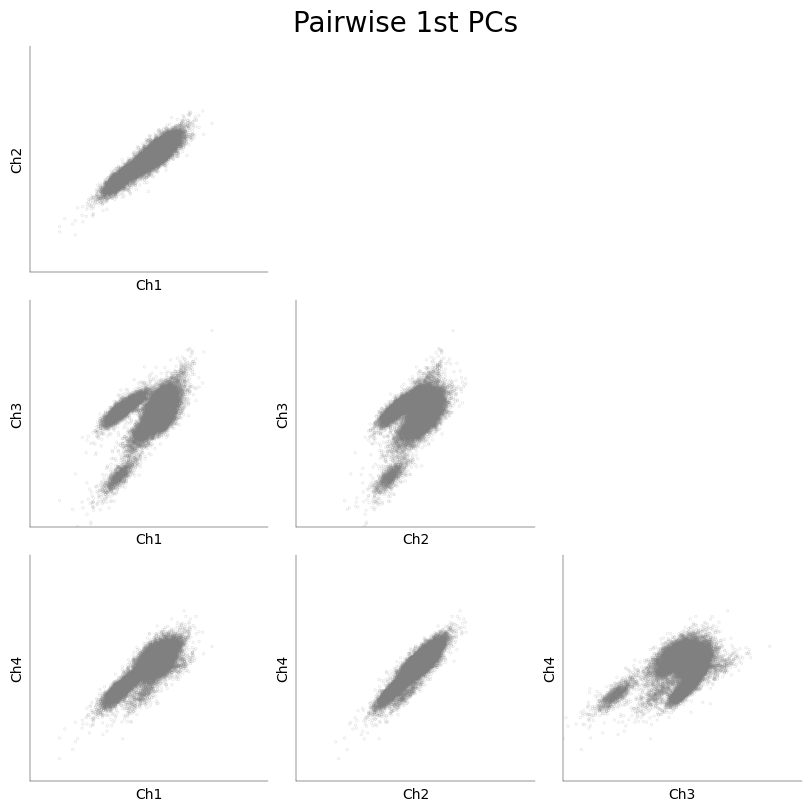

In [ ]:
# ----------------------------------------------------------------------------------------------------------
# Create a scatterplot of the projections of the spikes for all pairwise combinations of the 1st PCs (1 pt)
# ----------------------------------------------------------------------------------------------------------

mosaic = [
    ["Ch2 vs Ch1", ".", "."],
    ["Ch3 vs Ch1", "Ch3 vs Ch2", "."],
    ["Ch4 vs Ch1", "Ch4 vs Ch2", "Ch4 vs Ch3"],
]
fig, ax = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(8, 8), layout="constrained", dpi=100
)

# index of the 1st PC in `b`
i = {"Ch1": 0, "Ch2": 3, "Ch3": 6, "Ch4": 9}

for mo in np.ravel(mosaic):
    if mo == ".":
        continue
    y, x = mo.split(" vs ")

    ax[mo].set_xlabel(x)
    ax[mo].set_ylabel(y)
    ax[mo].set_xlim((-1500, 1500))
    ax[mo].set_ylim((-1500, 1500))
    ax[mo].set_xticks([])
    ax[mo].set_yticks([])

    # Add data
    ax[mo].scatter(
        b[:, i[x]],
        b[:, i[y]],
        color="gray",
        alpha=0.2,
        s=3,
        marker="o",
        facecolors="none",  # 核心：设置面色为空
        edgecolors="gray",  # 设置边框颜色
        linewidths=0.5,
    )

fig.suptitle("Pairwise 1st PCs", fontsize=20)

In [ ]:
# save data for the next Coding Lab

np.save("../data/nds_cl_1_features", b)
np.save("../data/nds_cl_1_spiketimes_s", s)
np.save("../data/nds_cl_1_spiketimes_t", t)
np.save("../data/nds_cl_1_waveforms", w)